In [23]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [24]:
DATASET_PATH = Path("../data/train_dataset_for_students")

IMG_PATH = DATASET_PATH / "img"
LABEL_PATH = DATASET_PATH / "labels"

splits = ["train", "val", "test"]

In [25]:
missing_masks = []
missing_images = []
matched = []

for split in splits:
    
    img_dir = IMG_PATH / split
    mask_dir = LABEL_PATH / split
    
    img_files = {f.stem: f for f in img_dir.glob("*.jpg")}
    mask_files = {f.stem: f for f in mask_dir.glob("*.png")}
    
    for name in img_files:
        if name not in mask_files:
            missing_masks.append((split, name))
        else:
            matched.append((split, name))
    
    for name in mask_files:
        if name not in img_files:
            missing_images.append((split, name))

In [26]:
print("Всего корректных пар:", len(matched))
print("Картинок без масок:", len(missing_masks))
print("Масок без картинок:", len(missing_images))

Всего корректных пар: 440
Картинок без масок: 0
Масок без картинок: 0


In [27]:
print("Примеры картинок без масок:")
print(missing_masks[:10])

print("Примеры масок без картинок:")
print(missing_images[:10])

Примеры картинок без масок:
[]
Примеры масок без картинок:
[]


In [28]:
invalid_masks = []
class_counter = Counter()

for split, name in matched:
    
    mask_path = LABEL_PATH / split / f"{name}.png"
    
    mask = Image.open(mask_path)
    arr = np.array(mask)
    
    unique_vals = np.unique(arr)
    
    if not set(unique_vals).issubset({0,1}):
        invalid_masks.append((mask_path, unique_vals))
    
    class_counter.update(arr.flatten())

In [29]:
import os
from pathlib import Path

DATASET_PATH = Path("../data/train_dataset_for_students")

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if "class" in f.lower() or "label" in f.lower() or "yaml" in f.lower():
            print(os.path.join(root, f))


In [30]:
print("Распределение классов:")
print(class_counter)

total_pixels = sum(class_counter.values())

for cls, count in class_counter.items():
    print(f"Class {cls}: {count/total_pixels:.4f}")

Распределение классов:
Counter({0: 25984601, 1: 1625365, 2: 1225874})
Class 0: 0.9011
Class 2: 0.0425
Class 1: 0.0564


In [31]:
print("Маски с неверными значениями:", len(invalid_masks))

for m in invalid_masks[:10]:
    print(m) 

Маски с неверными значениями: 220
(WindowsPath('../data/train_dataset_for_students/labels/train/000000016206_4014.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_students/labels/train/000000026730_391.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_students/labels/train/000000028253_7169.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_students/labels/train/000000030752_6513.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_students/labels/train/000000040466_5639.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_students/labels/train/000000045040_1484.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_students/labels/train/000000045587_1711.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_students/labels/train/000000046230_7013.png'), array([0, 2], dtype=uint8))
(WindowsPath('../data/train_dataset_for_student

In [32]:
samples = invalid_masks[:10]
samples

[(WindowsPath('../data/train_dataset_for_students/labels/train/000000016206_4014.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students/labels/train/000000026730_391.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students/labels/train/000000028253_7169.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students/labels/train/000000030752_6513.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students/labels/train/000000040466_5639.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students/labels/train/000000045040_1484.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students/labels/train/000000045587_1711.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students/labels/train/000000046230_7013.png'),
  array([0, 2], dtype=uint8)),
 (WindowsPath('../data/train_dataset_for_students

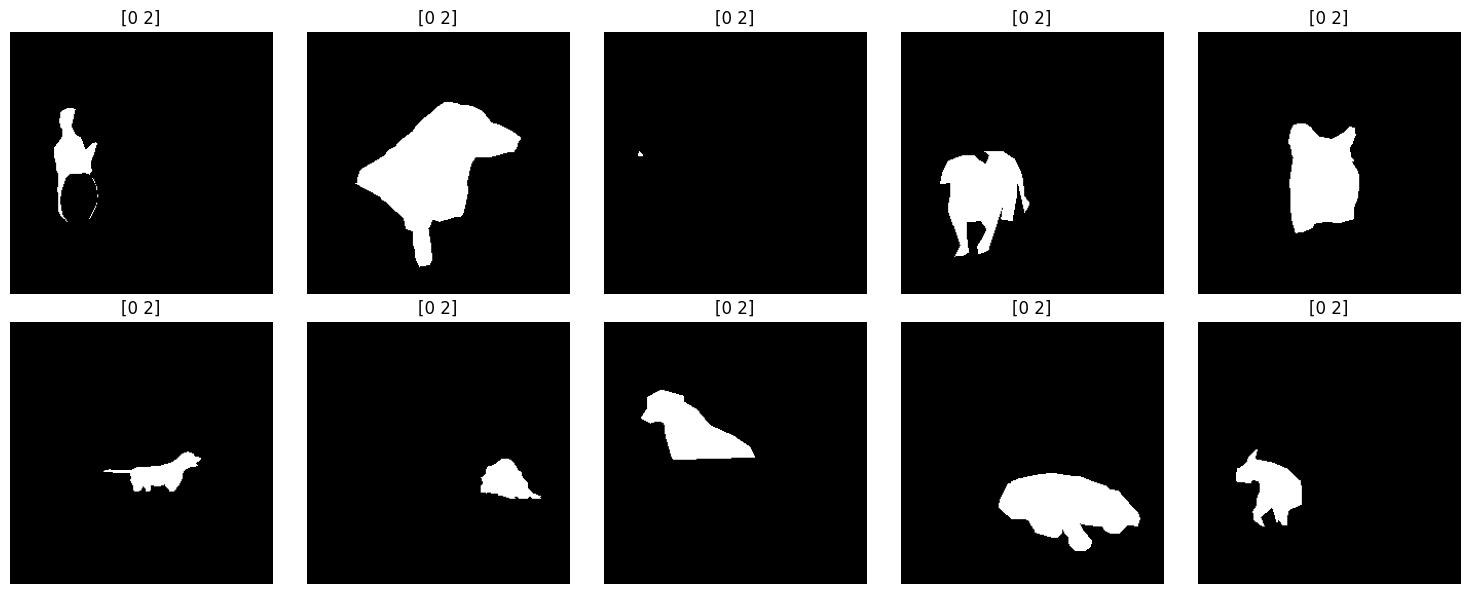

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

plt.figure(figsize=(15,6))

for i,(mask_path, vals) in enumerate(samples):

    mask = Image.open(mask_path)
    arr = np.array(mask)

    plt.subplot(2,5,i+1)
    plt.imshow(arr, cmap="gray")
    plt.title(f"{vals}")
    plt.axis("off")

plt.tight_layout()
plt.show()

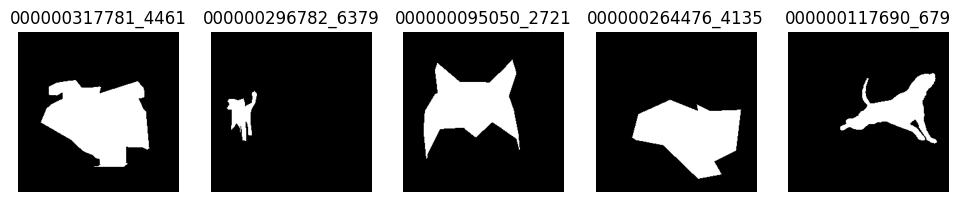

In [34]:
import random

samples = random.sample(matched, 5)

plt.figure(figsize=(12,6))

for i,(split,name) in enumerate(samples):
    
    mask_path = LABEL_PATH / split / f"{name}.png"
    
    mask = Image.open(mask_path)
    arr = np.array(mask)
    
    plt.subplot(1,5,i+1)
    plt.imshow(arr, cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.show()

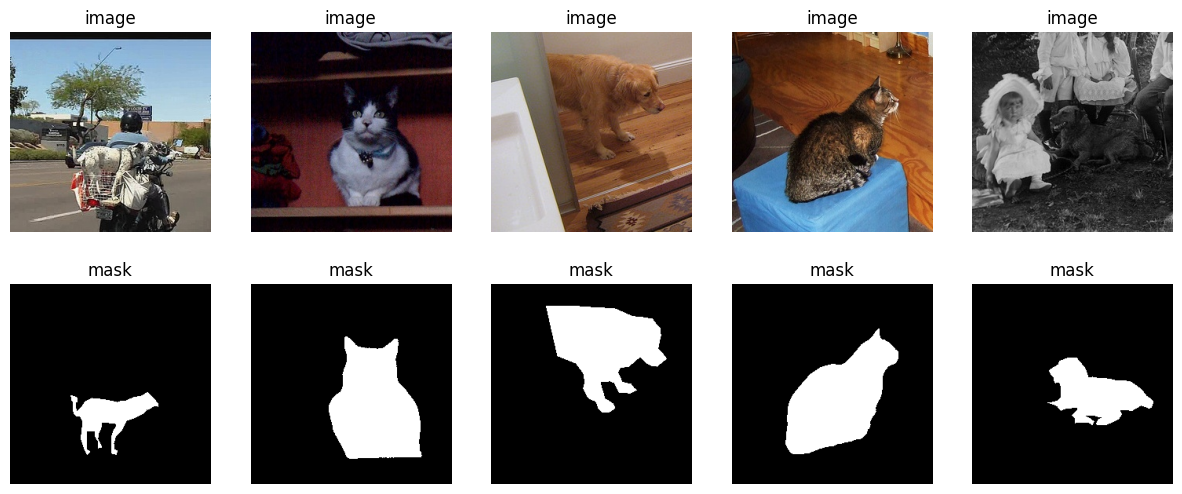

In [35]:
samples = random.sample(matched, 5)

plt.figure(figsize=(15,6))

for i,(split,name) in enumerate(samples):
    
    img_path = IMG_PATH / split / f"{name}.jpg"
    mask_path = LABEL_PATH / split / f"{name}.png"
    
    img = Image.open(img_path)
    mask = Image.open(mask_path)
    
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title("image")
    plt.axis("off")
    
    plt.subplot(2,5,i+6)
    plt.imshow(mask, cmap="gray")
    plt.title("mask")
    plt.axis("off")

plt.show()

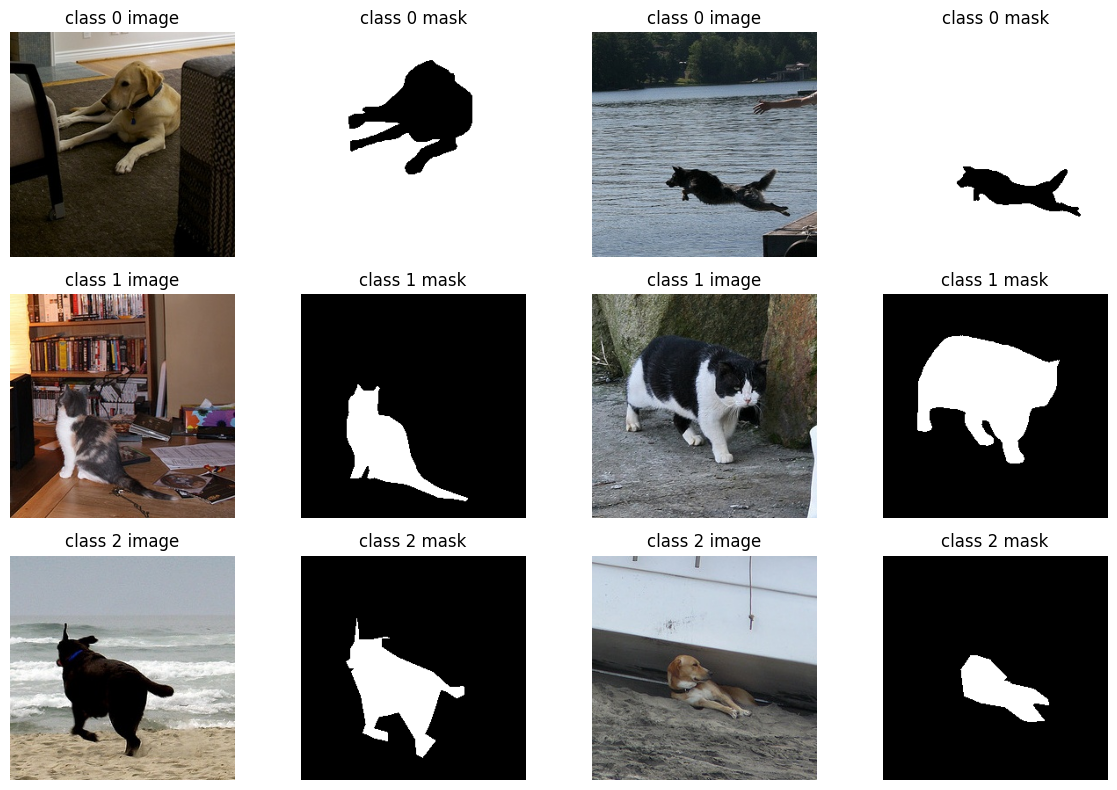

In [36]:
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

from collections import defaultdict

class_examples = defaultdict(list)

for split, name in matched:

    mask_path = LABEL_PATH / split / f"{name}.png"
    
    mask = Image.open(mask_path)
    arr = np.array(mask)

    classes = np.unique(arr)

    for c in classes:
        class_examples[c].append((split, name))

plot_id = 1

for cls in sorted(class_examples.keys()):

    samples = random.sample(class_examples[cls], 2)

    for split, name in samples:

        img_path = IMG_PATH / split / f"{name}.jpg"
        mask_path = LABEL_PATH / split / f"{name}.png"

        img = np.array(Image.open(img_path))
        mask = np.array(Image.open(mask_path))

        plt.subplot(3,4,plot_id)
        plt.imshow(img)
        plt.title(f"class {cls} image")
        plt.axis("off")

        plot_id += 1

        plt.subplot(3,4,plot_id)
        plt.imshow(mask==cls, cmap="gray")
        plt.title(f"class {cls} mask")
        plt.axis("off")

        plot_id += 1

plt.tight_layout()
plt.show()